## 트렌드 분석 (Trend Analysis)

```text
Trend Analysis
│
├── 1. Overall annual temperature
│   ├── 10-year Moving Average
│   ├── Linear Regression
│   ├── Mann-Kendall
│   └── Sen's Slope
│
├── 2. Summer temperature
│   ├── Linear Regression
│   ├── Mann-Kendall
│   └── Sen's Slope
│
├── 3. Winter temperature
│   ├── Linear Regression
│   ├── Mann-Kendall
│   └── Sen's Slope
│
└── 4. Days ≥ 35°C
    ├── Linear Regression
    ├── Mann-Kendall
    └── Sen's Slope
```

In [ ]:
%pip install scipy

Load annual temperature dataset generated in the previous step:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats   # for linear regression: stats.linregress(x, y)

df2 = pd.read_csv("../data/processed/dataset_processed.csv")
annual_temperature = pd.read_csv("../data/processed/annual_temperature.csv")

In [4]:
annual_temperature.head()

,year,avg_temp,avg_min_temp,avg_max_temp
0,1907,5.103261,0.067391,10.416304
1,1908,10.427322,5.799727,15.771858
2,1909,10.608767,5.832603,16.011507
3,1910,10.412055,5.752603,16.008767
4,1911,10.654795,6.035616,16.001644


In [5]:
x = annual_temperature["year"]
y = annual_temperature["avg_temp"]

### 1. Overall annual temperature

#### 1.1. 10-year Moving Average

Used 10-year moving average for this project. Moving average smooths short-term fluctuations so that the long-term pattern is easier to see.

In [7]:
annual_temperature["moving_avg_10y"] = (
    annual_temperature["avg_temp"]
    .rolling(window=10)
    .mean()
)

In [8]:
print(annual_temperature.head(10))

   year   avg_temp  avg_min_temp  avg_max_temp  moving_avg_10y
0  1907   5.103261      0.067391     10.416304             NaN
1  1908  10.427322      5.799727     15.771858             NaN
2  1909  10.608767      5.832603     16.011507             NaN
3  1910  10.412055      5.752603     16.008767             NaN
4  1911  10.654795      6.035616     16.001644             NaN
5  1912  10.123770      5.086885     15.646995             NaN
6  1913  10.086027      4.975068     15.651233             NaN
7  1914  12.029041      7.764658     17.061370             NaN
8  1915  10.898356      6.630411     15.906301             NaN
9  1916  10.911202      6.427322     16.545902        10.12546


In [9]:
print(annual_temperature.tail(10))

     year   avg_temp  avg_min_temp  avg_max_temp  moving_avg_10y
108  2017  13.073151      8.845205     18.123901       12.866103
109  2018  13.002466      8.871233     17.956986       12.869928
110  2019  13.598904      9.321096     18.602192       12.934476
111  2020  13.271858      9.389617     17.867213       13.047580
112  2021  13.752055      9.622466     18.491781       13.214566
113  2022  13.296164      9.207143     18.077808       13.317325
114  2023  14.109041     10.066027     18.800000       13.471873
115  2024  14.875410     10.975137     19.539891       13.619386
116  2025  14.150411     10.218904     18.697808       13.672236
117  2026  14.637662     10.267532     19.716017       13.776712


Visualize:

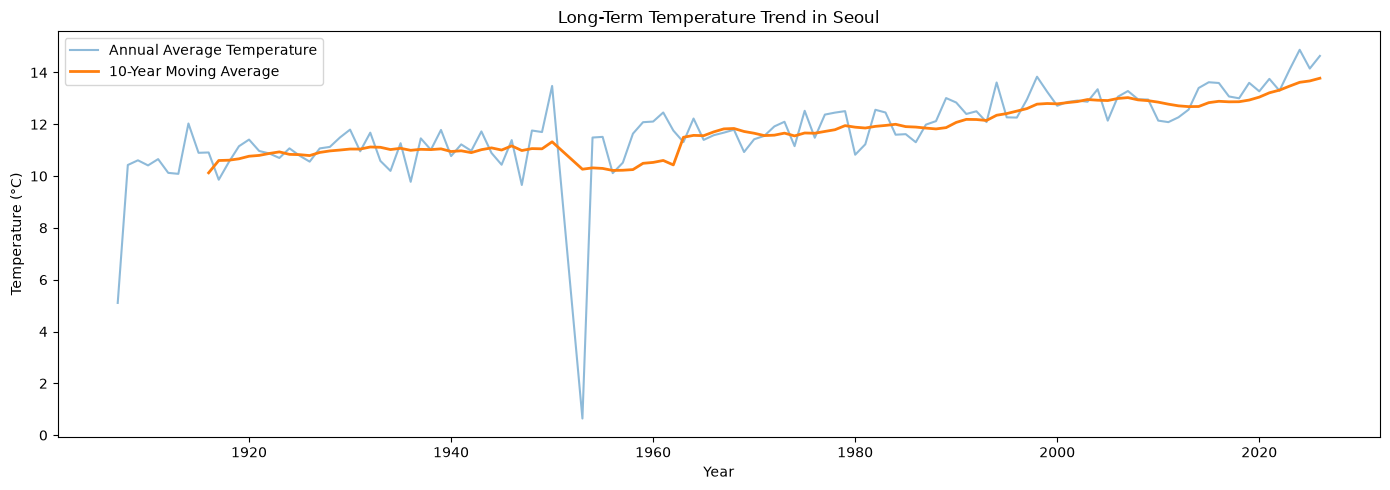

In [10]:
plt.figure(figsize=(14, 5))

plt.plot(
    annual_temperature["year"],
    annual_temperature["avg_temp"],
    label="Annual Average Temperature",
    alpha=0.5
)

plt.plot(
    annual_temperature["year"],
    annual_temperature["moving_avg_10y"],
    label="10-Year Moving Average",
    linewidth=2
)

plt.xlabel("Year")
plt.ylabel("Temperature (°C)")
plt.title("Long-Term Temperature Trend in Seoul")
plt.legend()
plt.tight_layout()
plt.show()

* 전반적으로 연평균 온도는 상승 추세에 있음.
* Moving average가 중간에 패인 모습을 하는 이유는 한국 전쟁기간에 데이터 포인트가 없기 때문.

### 1.2. Linear Regression

In [11]:
x = annual_temperature["year"]
y = annual_temperature["avg_temp"]

slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

print("Slope:", slope)
print("Intercept:", intercept)
print("R²:", r_value ** 2)
print("p-value:", p_value)
print("Standard error:", std_err)

Slope: 0.029468949774969937
Intercept: -46.21834263890643
R²: 0.4006345766853073
p-value: 1.472902639248478e-14
Standard error: 0.0033466268611900825


* The p-value is extremely low, so the positive linear trend is statistically significant 통계적으로 유의미 (p < 0.05). The relatively low R² ≈ 0.40 shows that year explains about 40% of the variation in annual average temperature, so there are substantial fluctuations around the overall warming trend.

Visualize:

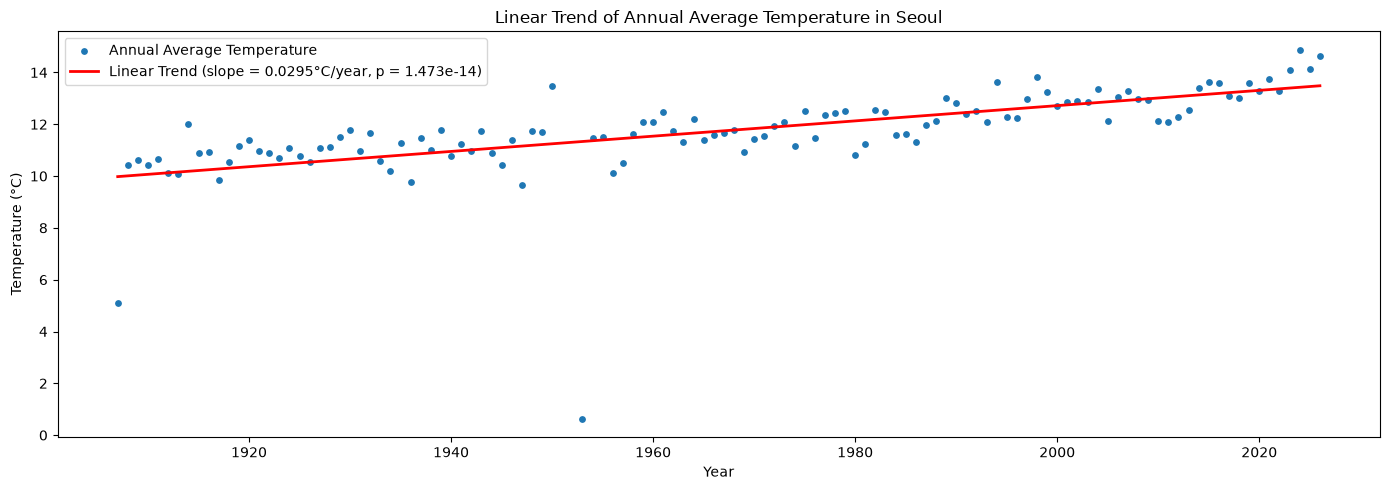

In [12]:
x = annual_temperature["year"]
y = annual_temperature["avg_temp"]

trend_line = intercept + slope * x

plt.figure(figsize=(14, 5))

plt.scatter(x, y, s=15, label="Annual Average Temperature")
plt.plot(x, trend_line, color="red", linewidth=2, label=f"Linear Trend (slope = {slope:.4f}°C/year, p = {p_value:.4g})")

plt.xlabel("Year")
plt.ylabel("Temperature (°C)")
plt.title("Linear Trend of Annual Average Temperature in Seoul")
plt.legend()
plt.tight_layout()
plt.show()

* 연평균 온도는 상승 추세에 있음. 

In [16]:
# 1907년과 1953년의 값은 이상치가 아닌 결측치 때문임:

print(annual_temperature[annual_temperature["avg_temp"] < 6])

    year  avg_temp  avg_min_temp  avg_max_temp  moving_avg_10y
0   1907  5.103261      0.067391     10.416304             NaN
44  1953  0.641935     -3.461290      4.551613       10.264821


Temperature change per 100 years: 100년 동안 연평균 온도는 ~2.95°C 정도 상승하고 있음.

In [13]:
change_per_100_years = slope * 100

print(
    f"Estimated temperature change per 100 years: "
    f"{change_per_100_years:.2f}°C"
)

Estimated temperature change per 100 years: 2.95°C


### 1.3. Mann–Kendall Test

Used `pymannkendall` package rather than implementing the test.

In [ ]:
%pip install pymannkendall

In [18]:
import pymannkendall as mk

y = annual_temperature["avg_temp"]

result = mk.original_test(y)
print(result)


Mann_Kendall_Test(trend='increasing', h=np.True_, p=np.float64(0.0), z=np.float64(10.443357321816123), Tau=np.float64(0.6505867014341591), s=np.float64(4491.0), var_s=184847.0, slope=np.float64(0.0273224043715847), intercept=np.float64(10.141776330563664))


In [19]:
print("Trend:", result.trend)
print("p-value:", result.p)
if result.p < 0.05:
    print(" > 통계적으로 유의한 추세가 있습니다.")
else:
    print(" > 통계적으로 유의한 추세가 확인되지 않았습니다.")
print("Kendall's Tau:", result.Tau)
print("Sen's slope:", result.slope)

Trend: increasing
p-value: 0.0
 > 통계적으로 유의한 추세가 있습니다.
Kendall's Tau: 0.6505867014341591
Sen's slope: 0.0273224043715847


* Trend: increasing & p-value: 0.0 → statistically significant increasing monotonic trend (통계적으로 유의미한 단조 증가 추세).
* Sen's slope: 0.027°C/year → estimated long-term increase is approximately 2.7°C / 100 year
    * Note: Sen's slope provides a robust estimate of the trend magnitude alongside the Mann–Kendall significance test.

## 2. Summer temperature 

In [21]:
summer_temperature = (
    df2[df2["season"] == "Summer"]
    .groupby("year")["tavg"]
    .mean()
    .reset_index(name="summer_avg_temp")
)

print(summer_temperature.head())

   year  summer_avg_temp
0  1908        22.872826
1  1909        23.510870
2  1910        22.463043
3  1911        22.961957
4  1912        23.077174


### 2.1. Linear Regression

In [28]:
summer_slope, summer_intercept, summer_r, summer_p, summer_std = (
    stats.linregress(
        summer_temperature["year"],
        summer_temperature["summer_avg_temp"]
    )
)

print("Summer slope:", summer_slope)
print("Summer intercept:", summer_intercept)
print("Summer R²:", summer_r ** 2)
print("Summer p-value:", summer_p)
print("Summer Standard error:", summer_std)
print("Summer change per 100 years:", summer_slope * 100)

Summer slope: 0.017474566931785084
Summer intercept: -10.298431710583781
Summer R²: 0.3419834634451519
Summer p-value: 5.47140507067867e-12
Summer Standard error: 0.002270229938907435
Summer change per 100 years: 1.7474566931785083


* The p-value is extremely low, so the positive linear trend is statistically significant 통계적으로 유의미 (p < 0.05). The relatively low R² ≈ 0.34 shows that year explains about 34% of the variation in annual average temperature.

### 2.2. Mann–Kendall Test

In [ ]:
summer_result = mk.original_test(summer_temperature["summer_avg_temp"])

print("Summer trend:", summer_result.trend)
print("Summer p-value:", summer_result.p)
print("Summer Sen's slope:", summer_result.slope)

Summer trend: increasing
Summer p-value: 2.1958457274706689e-10
Summer Sen's slope: 0.018081401654839006


* Trend: increasing & p-value: ~0.0 → statistically significant increasing monotonic trend (통계적으로 유의미한 단조 증가 추세).
* Sen's slope: 0.018°C/year → estimated long-term increase is approximately 1.8°C / 100 year
    * Note: Sen's slope provides a robust estimate of the trend magnitude alongside the Mann–Kendall significance test.

## 3. Winter temperature

In [25]:
winter_temperature = (
    df2[df2["season"] == "Winter"]
    .groupby("year")["tavg"]
    .mean()
    .reset_index(name="winter_avg_temp")
)

print(winter_temperature.head())

   year  winter_avg_temp
0  1907        -3.890323
1  1908        -2.751648
2  1909        -3.058889
3  1910        -3.427778
4  1911        -3.063333


### 3.1. Linear Regression

In [29]:
winter_slope, winter_intercept, winter_r, winter_p, winter_std = (
    stats.linregress(
        winter_temperature["year"],
        winter_temperature["winter_avg_temp"]
    )
)

print("Winter slope:", winter_slope)
print("Winter intercept:", winter_intercept)
print("Winter R²:", winter_r ** 2)
print("Winter p-value:", winter_p)
print("Winter Standard error:", winter_std)
print("Winter change per 100 years:", winter_slope * 100)

Winter slope: 0.02852267371390029
Winter intercept: -57.80460700574288
Winter R²: 0.37368798135596765
Winter p-value: 1.951716044618003e-13
Winter Standard error: 0.003428483367837387
Winter change per 100 years: 2.8522673713900293


* The p-value is extremely low, so the positive linear trend is statistically significant 통계적으로 유의미 (p < 0.05). The relatively low R² ≈ 0.37 shows that year explains about 37% of the variation in annual average temperature.

### 3.2. Mann–Kendall Test

In [ ]:
winter_result = mk.original_test(winter_temperature["winter_avg_temp"])

print("Winter trend:", winter_result.trend)
print("Winter p-value:", winter_result.p)
print("Winter Sen's slope:", winter_result.slope)

Winter trend: increasing
Winter p-value: 8.150147223773274e-12
Winter Sen's slope: 0.02935555555555556


* Trend: increasing & p-value: ~0.0 → statistically significant increasing monotonic trend (통계적으로 유의미한 단조 증가 추세).
* Sen's slope: 0.029°C/year → estimated long-term increase is approximately 2.9°C / 100 year
    * Note: Sen's slope provides a robust estimate of the trend magnitude alongside the Mann–Kendall significance test.

> 서울의 여름(6월~8월)과 겨울(12월~2월)의 평균온도는 증가 추세에 있으며, 100년 동안 여름 평균온도 증가보다 겨울 평균온도 증가가 ~1°C 정도 높음 (여름 1.8°C vs 겨울 2.9°C).

## 4. Days ≥ 35°C

In [30]:
import pandas as pd

annual_over_35 = pd.read_csv("../data/processed/annual_over_35.csv")

print(annual_over_35.head())
print(annual_over_35.tail())

   year  days_over_35
0  1907             0
1  1908             0
2  1909             1
3  1910             0
4  1911             0
     year  days_over_35
113  2022             2
114  2023             1
115  2024             6
116  2025            13
117  2026             7


### 4.1. Linear Regression

In [31]:
slope_35, intercept_35, r_35, p_35, std_35 = stats.linregress(
    annual_over_35["year"],
    annual_over_35["days_over_35"]
)

print("Over 35 slope:", slope_35)
print("Over 35 intercept:", intercept_35)
print("Over 35 R²:", r_35 ** 2)
print("Over 35 p-value:", p_35)
print("Over 35 Standard error:", winter_std)
print("Over 35 change per 100 years:", slope_35 * 100)

Over 35 slope: 0.0034794728460772386
Over 35 intercept: -4.173776438127689
Over 35 R²: 0.0006474033129439662
Over 35 p-value: 0.7844720310383352
Over 35 Standard error: 0.003428483367837387
Over 35 change per 100 years: 0.34794728460772384


* 통계적으로 유의하지 않음 (p = 0.784 > 0.05). 또한 R² ≈ 0.00065로 매우 낮아, 장기적으로 35°C 이상인 날의 수가 증가한다고 볼 수 있는 선형 추세가 거의 나타나지 않음. 100년당 약 0.35일 증가라는 추정치도 통계적으로 신뢰할 만한 증가 추세라고 해석하기 어려움.


Visualize:

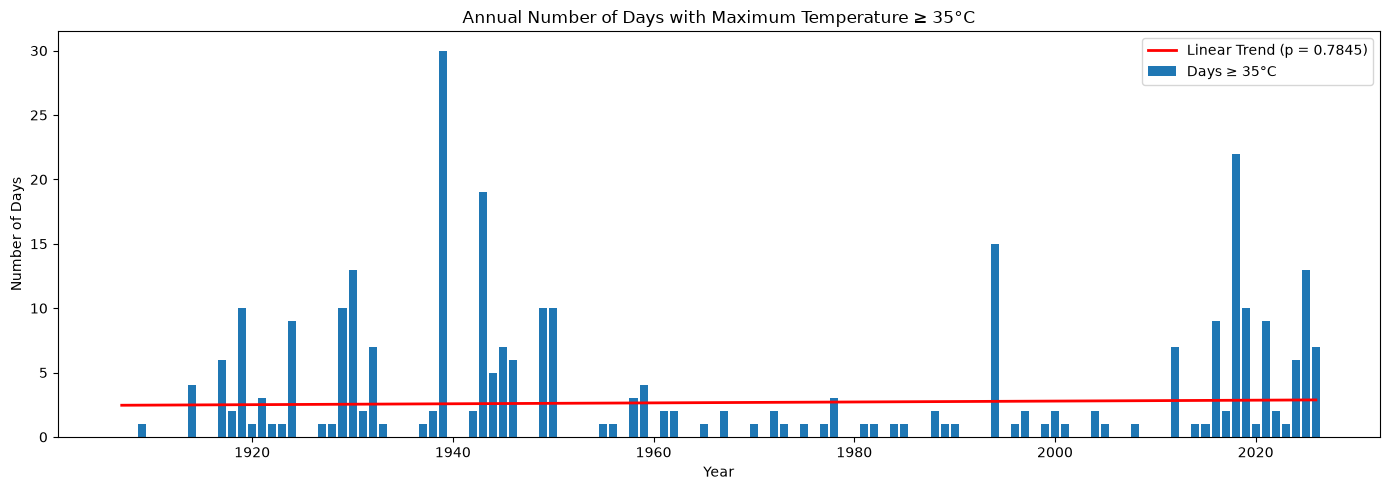

In [35]:
trend_35 = (intercept_35 + slope_35 * annual_over_35["year"])

plt.figure(figsize=(14, 5))

plt.bar(
    annual_over_35["year"],
    annual_over_35["days_over_35"],
    label="Days ≥ 35°C"
)

plt.plot(
    annual_over_35["year"],
    trend_35,
    color="red",
    linewidth=2,
    label=f"Linear Trend (p = {p_35:.4g})"
)

plt.xlabel("Year")
plt.ylabel("Number of Days")
plt.title("Annual Number of Days with Maximum Temperature ≥ 35°C")
plt.legend()

plt.tight_layout()
plt.show()

* Regression line이 거의 일직선이고 bar graph에서도 볼 수 있듯이 35도 이상인 날의 수가 년마다 증가한다고 볼 수 없음. 2020년대에는 35도 이상의 날이 5~15일인 구간에 있는데 언제까지 지속될지 알 수 없음.

### 4.2. Mann–Kendall Test

In [32]:
result_35 = mk.original_test(
    annual_over_35["days_over_35"]
)

print("Trend:", result_35.trend)
print("p-value:", result_35.p)
print("Sen's slope:", result_35.slope)

Trend: no trend
p-value: 0.4750867171372275
Sen's slope: 0.0


* Not statistically significant trend because p = 0.475 > 0.05; the Sen’s slope of 0.0 likewise suggests essentially no detectable monotonic change in the annual number of days ≥35°C.

## 5. Saving the trend-analysis results

In [36]:
trend_results = pd.DataFrame({
    "dataset": [
        "Annual Average Temperature",
        "Summer Average Temperature",
        "Winter Average Temperature",
        "Days ≥ 35°C"
    ],
    "linear_slope_per_year": [
        slope,
        summer_slope,
        winter_slope,
        slope_35
    ],
    "linear_p_value": [
        p_value,
        summer_p,
        winter_p,
        p_35
    ],
    "linear_r_value": [
        r_value,
        summer_r,
        winter_r,
        r_35
    ],
    "mann_kendall_trend": [
        result.trend,
        summer_result.trend,
        winter_result.trend,
        result_35.trend
    ],
    "mann_kendall_p_value": [
        result.p,
        summer_result.p,
        winter_result.p,
        result_35.p
    ],
    "sen_slope": [
        result.slope,
        summer_result.slope,
        winter_result.slope,
        result_35.slope
    ]
})

print(trend_results)

trend_results.to_csv(
    "../data/processed/trend_analysis_results.csv",
    index=False,
    encoding="utf-8-sig"
)

                      dataset  linear_slope_per_year  linear_p_value  \
0  Annual Average Temperature               0.029469    1.472903e-14   
1  Summer Average Temperature               0.017475    5.471405e-12   
2  Winter Average Temperature               0.028523    1.951716e-13   
3                 Days ≥ 35°C               0.003479    7.844720e-01   

   linear_r_value mann_kendall_trend  mann_kendall_p_value  sen_slope  
0        0.632957         increasing          0.000000e+00   0.027322  
1        0.584794         increasing          2.195846e-10   0.018081  
2        0.611300         increasing          8.150147e-12   0.029356  
3        0.025444           no trend          4.750867e-01   0.000000  


> Note: 

> Because the data are a long climate time series, the basic Mann–Kendall test should not automatically be treated as the final statistical answer if serial autocorrelation is present. Autocorrelation can affect the significance of the MK test, and specialized approaches such as trend-free prewhitening or other autocorrelation-aware methods are commonly used in climate/hydrological trend analysis.

> The basic MK test was carried out to understand the results, but before writing the final methodology/report, should check the annual series for autocorrelation and decide whether an autocorrelation-adjusted MK test is appropriate.